In [5]:

import numpy as np
import scipy.io as sio
MAT_PATH = '/mnt/d/GaTech Dropbox/Haoyu Xu/workspace/DDS2M/exp/datasets/ood_msi/bcars_denoising.mat'

_raw_mat = sio.loadmat(MAT_PATH)
# Noisy observation cube, shape (H, W, C), values in [0, 1].
Z_noisy = np.asarray(_raw_mat['y_0_real'], dtype=np.float64)[0:50, 0:50, :]


In [17]:
EXTRA_SOURCE_NPZ = (
    '/mnt/d/cross-covariance-denoising/data/test/'
    'bcars_batched_fit_2026-05-07_17-26-16_preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_05'
    '_PROCESS_202657_14_45_24_362743_PROCESS_202657_14_58_5_69804_tolerance=1e-05_with_Znoisy.npz'
)
_src = np.load(EXTRA_SOURCE_NPZ)
noisy_bcars = _src['noisy_bcars']

In [24]:
nrb_amp_normed = _src['nrb_amp_normed']
nrb_I = nrb_amp_normed ** 2

In [20]:
noisy_bcars_clip = noisy_bcars[0:50, 0:50, :]

In [6]:
H, W, C = Z_noisy.shape
print(f"noisy cube y_0_real: shape={Z_noisy.shape}, "
      f"min={Z_noisy.min():.4g}, max={Z_noisy.max():.4g}")

noisy cube y_0_real: shape=(50, 50, 695), min=0.132, max=0.8484


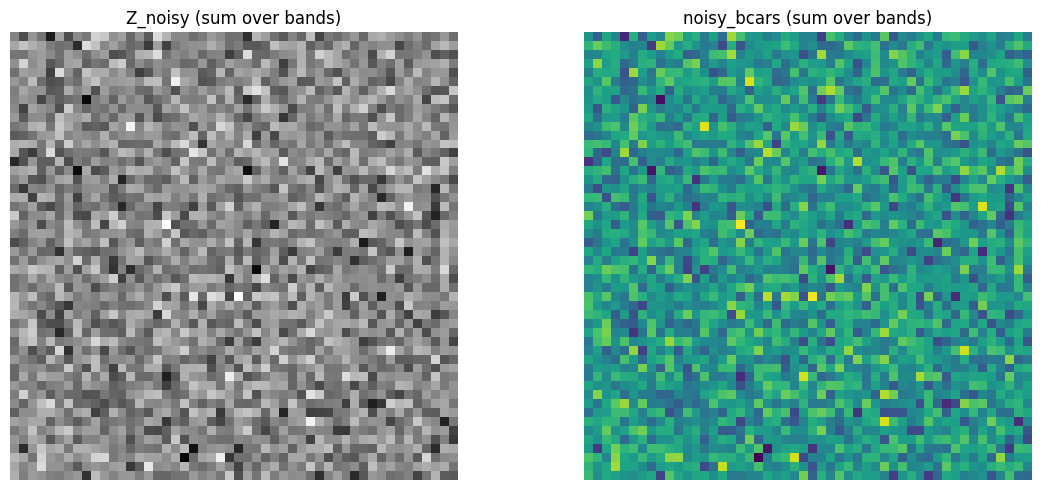

In [21]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.sum(Z_noisy, axis=2), cmap='gray')
axes[0].set_title('Z_noisy (sum over bands)')
axes[0].axis('off')
axes[1].imshow(np.sum(noisy_bcars_clip, axis=2), cmap='gray')
axes[1].set_title('noisy_bcars (sum over bands)')
axes[1].axis('off')
plt.tight_layout()
plt.imshow(np.sum(Z_noisy, axis=2))
plt.show()


In [9]:
MAD_SCALE = 0.6744897501960817  # Phi^-1(0.75); makes MAD a consistent sigma estimator

def sigma_mad_haar(cube):
    """Donoho robust estimator: MAD of the finest-scale Haar diagonal (HH)
    wavelet detail, computed per band then aggregated by median over bands.
    Diagonal detail strongly suppresses smooth signal, leaving mostly noise."""
    a = cube[0:H - H % 2:2, 0:W - W % 2:2, :]
    b = cube[0:H - H % 2:2, 1:W - W % 2:2, :]
    c = cube[1:H - H % 2:2, 0:W - W % 2:2, :]
    d = cube[1:H - H % 2:2, 1:W - W % 2:2, :]
    hh = (a - b - c + d) / 2.0  # normalized so noise std is preserved
    per_band = np.median(np.abs(hh), axis=(0, 1)) / MAD_SCALE
    return float(np.median(per_band)), per_band


def sigma_laplacian(cube):
    """Immerkaer (1996) fast noise estimator using a Laplacian-difference mask,
    which cancels locally-linear signal. Per band, aggregated by median."""
    # interior second-difference response of mask [[1,-2,1],[-2,4,-2],[1,-2,1]]
    L = (cube[0:-2, 0:-2, :] + cube[0:-2, 2:, :] + cube[2:, 0:-2, :] + cube[2:, 2:, :]
         - 2 * (cube[0:-2, 1:-1, :] + cube[2:, 1:-1, :]
                + cube[1:-1, 0:-2, :] + cube[1:-1, 2:, :])
         + 4 * cube[1:-1, 1:-1, :])
    scale = np.sqrt(np.pi / 2.0) / 6.0
    per_band = scale * np.mean(np.abs(L), axis=(0, 1))
    return float(np.median(per_band)), per_band


def sigma_finite_diff(cube, axis):
    """Neighbor finite-difference estimator: sigma = sqrt(var(diff)/2).
    Biased high by true signal gradients; reported as an upper sanity bound."""
    dz = np.diff(cube, axis=axis)
    return float(np.sqrt(dz.var() / 2.0))


sigma_mad, mad_bands = sigma_mad_haar(Z_noisy)
sigma_lap, lap_bands = sigma_laplacian(Z_noisy)
sigma_spatial = sigma_finite_diff(Z_noisy, axis=0)
sigma_spectral = sigma_finite_diff(Z_noisy, axis=2)

print("\n--- white-noise sigma estimates (in [0,1] data units) ---")
print(f"MAD Haar-diagonal (robust):   {sigma_mad:.5f}   "
      f"[per-band spread: {mad_bands.min():.5f}-{mad_bands.max():.5f}]")
print(f"Laplacian (Immerkaer):        {sigma_lap:.5f}")
print(f"spatial finite-diff (upper):  {sigma_spatial:.5f}")
print(f"spectral finite-diff (upper): {sigma_spectral:.5f}")


--- white-noise sigma estimates (in [0,1] data units) ---
MAD Haar-diagonal (robust):   0.06996   [per-band spread: 0.06109-0.08171]
Laplacian (Immerkaer):        0.07004
spatial finite-diff (upper):  0.07001
spectral finite-diff (upper): 0.06987


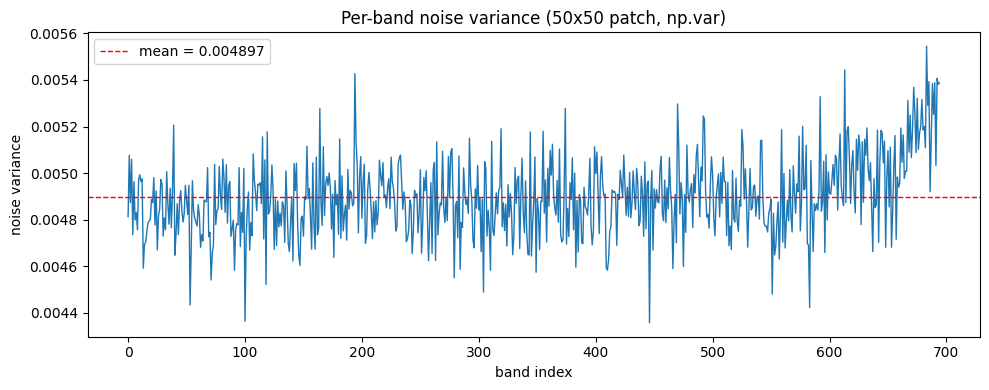

band_var: min=0.00436, max=0.00555, mean=0.0049, std/mean=0.0342


In [27]:
# Per-band noise variance: Z_noisy is already the 50x50 pure-noise patch,
# so the plain variance of each band's 2500 pixels IS its noise variance.
# A constant DC offset does not affect variance, so no signal-cancellation
# trick is needed. If the cube is variance-whitened, this curve is ~flat.
band_var = Z_noisy.reshape(-1, C).var(axis=0)   # one variance per band

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(band_var, lw=1)
ax.axhline(band_var.mean(), color='r', ls='--', lw=1,
           label=f'mean = {band_var.mean():.4g}')
ax.set_xlabel('band index')
ax.set_ylabel('noise variance')
ax.set_title('Per-band noise variance (50x50 patch, np.var)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"band_var: min={band_var.min():.3g}, max={band_var.max():.3g}, "
      f"mean={band_var.mean():.3g}, std/mean={band_var.std()/band_var.mean():.3g}")

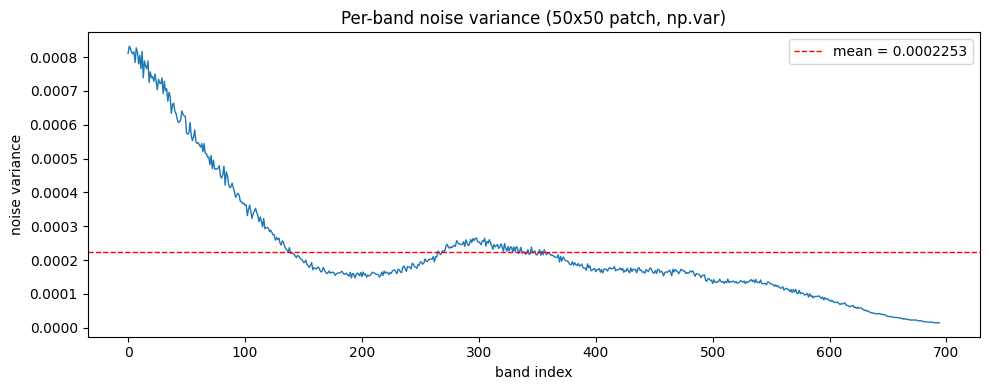

band_var: min=1.45e-05, max=0.000832, mean=0.000225, std/mean=0.783


In [38]:
# Per-band noise variance: Z_noisy is already the 50x50 pure-noise patch,
# so the plain variance of each band's 2500 pixels IS its noise variance.
# A constant DC offset does not affect variance, so no signal-cancellation
# trick is needed. If the cube is variance-whitened, this curve is ~flat.
band_var = noisy_bcars_clip.reshape(-1, C).var(axis=0)   # one variance per band

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(band_var, lw=1)
ax.axhline(band_var.mean(), color='r', ls='--', lw=1,
           label=f'mean = {band_var.mean():.4g}')
ax.set_xlabel('band index')
ax.set_ylabel('noise variance')
ax.set_title('Per-band noise variance (50x50 patch, np.var)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"band_var: min={band_var.min():.3g}, max={band_var.max():.3g}, "
      f"mean={band_var.mean():.3g}, std/mean={band_var.std()/band_var.mean():.3g}")

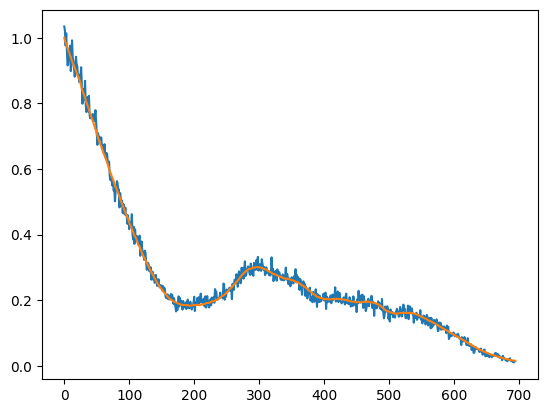

In [36]:
plt.plot(noisy_bcars_clip[0,0,:], label='noisy_bcars_clip')
plt.plot(nrb_I, label='nrb_I')

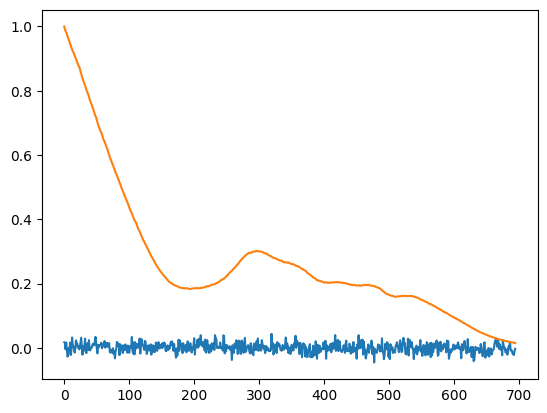

In [40]:
plt.plot((noisy_bcars_clip[0,0,:]-nrb_I)/(2*nrb_amp_normed), label='noisy_bcars_clip')
plt.plot(nrb_I, label='nrb_I')